# 00 - Setup & the synthetic graph suite

Welcome to a hands-on series on **Graph Neural Networks (GNNs)**. The companion
series next door took apart gradient-boosted trees for *tabular* data; this one
asks the natural follow-up question:

> What changes when your data isn't a flat table of independent rows, but a
> **graph** - entities connected by relationships?

### The trick that makes this series work (same as the GBDT series)

We **don't** start from a messy real dataset. We *generate* graphs where **we**
plant the signal - sometimes in the node features, sometimes in the local
structure, sometimes far away across the graph. Because we know the ground truth,
every notebook can ask a sharp question instead of just "what's the accuracy?":

> Did the GNN recover the structure we planted - and did it ignore the noise?

This first notebook checks the environment, recaps the vocabulary of graphs, and
generates + visualises the synthetic suite the rest of the series reuses.

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # make utils/ importable from notebooks/

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
torch.manual_seed(0); np.random.seed(0)

from utils import graphs as G     # synthetic graph generators (known ground truth)
from utils import models as M     # the model zoo (MLP, GCN, SAGE, GAT, GIN, GPS, ...)
from utils import training as T    # train/eval loops + metrics
from utils import plotting as P    # graph drawing, curves, comparisons


In [2]:
# Environment check - confirm the graph stack imports and reports versions.
import torch_geometric, networkx as nx, sklearn
print("torch           ", torch.__version__)
print("torch_geometric ", torch_geometric.__version__)
print("networkx        ", nx.__version__)
print("scikit-learn    ", sklearn.__version__)
print("CUDA available  ", torch.cuda.is_available(), "(CPU is plenty for these toy graphs)")

torch            2.12.0+cpu
torch_geometric  2.8.0
networkx         3.6.1
scikit-learn     1.8.0
CUDA available   False (CPU is plenty for these toy graphs)


## Graph 101 - the three things you need

A graph is **nodes** (entities) + **edges** (relationships). In PyTorch Geometric a
graph is a `Data` object with:

- `x`  - a node-feature matrix, shape `[num_nodes, num_features]`
- `edge_index` - a `[2, num_edges]` integer tensor; column `[u, v]` means "edge u->v".
  Undirected edges are stored as *both* `[u, v]` and `[v, u]`.
- `y`  - labels/targets (per node, per edge, or per graph depending on the task)

There are **three task levels**, and which one you have decides almost everything:

| Level | Predict... | Example |
|---|---|---|
| **Node** | a label per node | is this account fraudulent? |
| **Edge / Link** | whether/what edge exists | will these two users connect? |
| **Graph** | a label per whole graph | is this molecule toxic? |

Let's build a tiny graph by hand to make `edge_index` concrete.

Data(x=[4, 4], edge_index=[2, 8])
num_nodes: 4  num_edges (directed): 8
adjacency:
 [[0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]
 [1 0 1 0]]


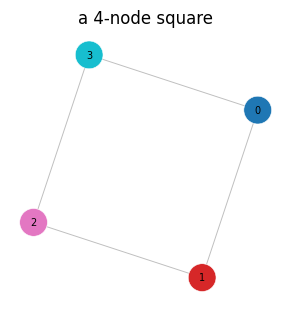

In [3]:
# A 4-node graph:  0-1, 1-2, 2-3, 3-0  (a square)
import networkx as nx
from torch_geometric.data import Data

edge_index = torch.tensor([[0,1,1,2,2,3,3,0],
                           [1,0,2,1,3,2,0,3]], dtype=torch.long)  # both directions
x = torch.eye(4)                       # a trivial one-hot feature per node
toy = Data(x=x, edge_index=edge_index)
print(toy)
print("num_nodes:", toy.num_nodes, " num_edges (directed):", toy.num_edges)

# The adjacency matrix is just a different view of edge_index:
A = torch.zeros(4,4); A[edge_index[0], edge_index[1]] = 1
print("adjacency:\n", A.int().numpy())

fig, ax = plt.subplots(figsize=(3.5,3.5))
P.draw_graph(toy, node_color=[0,1,2,3], title="a 4-node square", ax=ax, layout="spring",
             node_size=400, with_labels=True)
plt.show()

## The synthetic suite

Six generators live in `utils/graphs.py`. Each returns a PyG `Data` (or a list of
graphs) **plus** a `GraphGroundTruth` describing exactly what we planted. Here's the
whole cast - we'll use them throughout the series:

| Generator | Task | Where the signal lives |
|---|---|---|
| `make_neighbor_aggregation_regression(lambda)` | node regression | own features **+ lambda-neighbour mean** |
| `make_sbm_homophily(homophily)` | node classification | features **+ community structure** |
| `make_heterophilous_graph()` | node classification | structure, but neighbours are *opposite* class |
| `make_structural_role()` | node classification | **pure local structure** (features are noise) |
| `make_expressivity_graphs()` | graph classification | **degree/density** (constant features) |
| `make_ring_transfer()` | graph classification | a **far-away** node (long-range) |

Let's generate a few and read their ground-truth cards.

In [4]:
reg, gt_reg = G.make_neighbor_aggregation_regression(structure_weight=2.0)
sbm, gt_sbm = G.make_sbm_homophily(homophily=0.85)
het, gt_het = G.make_heterophilous_graph(homophily=0.2)

print("- neighbour-aggregation regression -")
display(gt_reg.summary())
print("\n- SBM (homophilous) -")
display(gt_sbm.summary())

- neighbour-aggregation regression -


,value
task,node_regression
description,y = own-feature effect + lambda * neighbour-me...
n_features,8
own_feature_effect,"x0:+1.50, x1:-1.00"
neighbor_mean_effect,"x2:+1.20, x3:-0.80"
structure_weight (lambda),2.0
n_nodes,800
noise_features,"[x4, x5, x6, x7]"



- SBM (homophilous) -


,value
task,node_classification
description,SBM: label = community. Features carry partial...
n_features,10
edge_homophily,0.848
n_classes,3
feature_signal,0.6
requested_homophily,0.85


## Seeing homophily vs heterophily

**Homophily** = "birds of a feather": connected nodes tend to share a label. It is the
hidden assumption behind the most famous GNN (GCN). When it *fails* (heterophily),
many GNNs quietly break - a theme we return to in notebook 07.

The `homophily` knob literally sets the fraction of each node's edges that stay
inside its own class. Below: same number of nodes/classes, opposite structure.

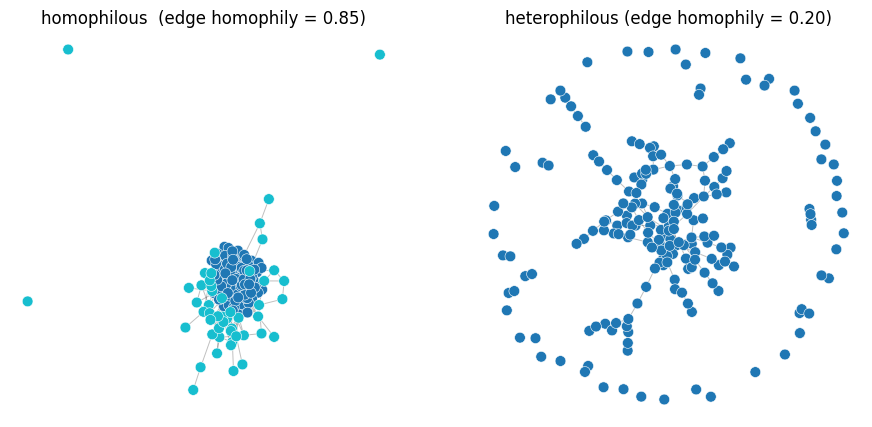

Edge homophily = fraction of edges whose endpoints share a label.
  homophilous graph : 0.848
  heterophilous graph: 0.200


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
P.draw_graph(sbm, title=f"homophilous  (edge homophily = {gt_sbm.homophily:.2f})",
             ax=axes[0], max_nodes=200)
P.draw_graph(het, title=f"heterophilous (edge homophily = {gt_het.homophily:.2f})",
             ax=axes[1], max_nodes=200)
plt.show()

print("Edge homophily = fraction of edges whose endpoints share a label.")
print(f"  homophilous graph : {G.homophily_ratio(sbm.edge_index, sbm.y):.3f}")
print(f"  heterophilous graph: {G.homophily_ratio(het.edge_index, het.y):.3f}")

## The question we'll keep asking

For every architecture in this series we will check, on data whose answer we already
know:

1. **Does reading the graph help at all?** (vs an MLP that ignores edges)
2. **Which planted structure does this model capture - and which does it miss?**
3. **When should you reach for it, and when for something else (incl. a GBDT)?**

Next up - **notebook 01**: we build message passing *from scratch* and watch a GNN
solve something an MLP provably cannot.